In [ ]:
# In this notebook I simulate Grover's Algorithm in an n-qubit database with ideal quantum gates

In [9]:
!pip install qiskit numpy matplotlib qiskit[visualization]

In [10]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import PhaseOracleGate
from qiskit.circuit.library import grover_operator
import numpy as np
import matplotlib.pyplot as plt
import math

In [11]:
# This cell is for determining parameters of the algorithm, including how many qubits the circuit will have
n = 10

Target = np.random.randint(low=0, high=2, size=n)
print(Target)
# This creates a random bitstring that we will be searching for with Grover's Algorithm

[0 1 0 1 0 0 1 0 0 0]


In [12]:
# We will now create the argument for the phase oracle gate

TargetExpression = ""
for i in range(n):
  if Target[i] == 1:
    TargetExpression += "x" + str(i) + " & "
  elif Target[i] == 0:
    TargetExpression += "~x" + str(i) + " & "

TargetExpression = TargetExpression[:-2]
#removes the & at the end

print(TargetExpression)

~x0 & x1 & ~x2 & x3 & ~x4 & ~x5 & x6 & ~x7 & ~x8 & ~x9 


{'0001001010': 95, '1001011001': 1, '0011101011': 1, '0101111000': 1, '0110101000': 1, '1100010010': 1}


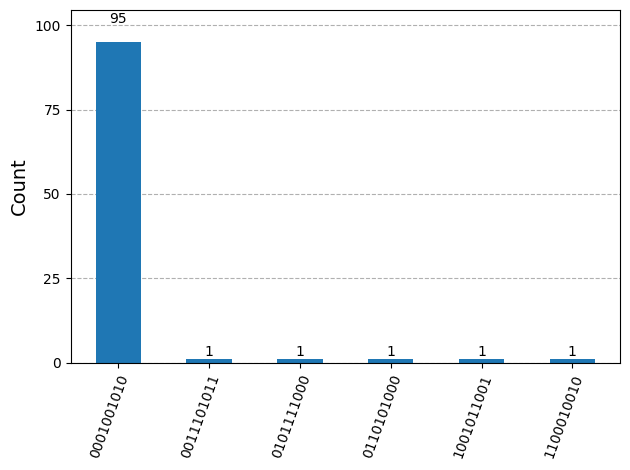

In [13]:
# Here is the actual implementation of Grover's Algorithm

Grovers = QuantumCircuit(n)

Grovers.h(range(n))
for i in range(int(math.ceil(((math.pi)/4*(math.sqrt(2**n)))) + 1)):
# Calculates how many times Grover's operation needs to be applied to converge on the target string absolutely

  Grovers = Grovers.compose(grover_operator(PhaseOracleGate(TargetExpression)), range(n))
  #Repeat the phase oracle and diffusion steps 27 times (when n = 10). 27 is approximately the number of iterations to optimally converge
  # Grover's Algorithm needs pi/4 * sqrt(2^n) = 25.13 iterations to converge absolutely


# Measure and record our qubits' states
Grovers.measure_all()
sampler = StatevectorSampler()
result = sampler.run([Grovers], shots = 100).result()
counts = result[0].data.meas.get_counts()
print(result[0].data.meas.get_counts())
plot_histogram(counts)

# YESSSSSS IT WORKSSSSS - Russell at time of completion

